# $^6$He Gadget — Rydberg Blockade Constraint

This notebook mirrors `GadgetHe6.ipynb` but replaces the uniform particle-conservation constraint
$$H_C = \gamma\left(\sum_A N_A - 1\right)^2 = 2\gamma\sum_{A<B}N_AN_B + \gamma(1-2)\sum_A N_A + \gamma$$
with the **Rydberg blockade constraint**
$$H_C^{\rm Ryd} = V\sum_{A<B} N_A N_B - \Delta\sum_A N_A$$
where $V = C_6/a^6$ is the van der Waals interaction and $\Delta$ is the laser detuning.

**Key observation for $^6$He ($n=3$ qubits on an equilateral triangle):**  
All 3 pairs have the same distance $a$, so $V_{AB} = V$ for every pair.  
The Rydberg constraint is therefore **automatically uniform** — identical in structure
to the standard one with $\gamma = \Delta$, provided $\Delta \ll V$.

**Spectrum:**
- $E_{N=0} = 0$
- $E_{N=1} = -\Delta$ (3-fold degenerate, gap $\Delta$ below $N=0$)
- $E_{N=2} = V - 2\Delta$ (gap $V - \Delta$ above $N=1$)

**Effective coupling** (BW second order in $d_A$):
$$g_{AB}^{\rm eff} = -\frac{d_A d_B}{\Delta} - \frac{d_A d_B}{V - \Delta} \approx -\frac{d_A d_B}{\Delta} \quad (\Delta \ll V)$$
This is **identical** to $-d_A d_B/\gamma$ with $\gamma = \Delta$.

## 0. Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import fidelity

import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))
from utils import computational_basis, build_effective_hamiltonian
from ManyBodyQutip.qutip_class import SpinOperator

np.set_printoptions(precision=4, suppress=True)

## 1. NSM data and quasiparticle Hamiltonian
Identical to `GadgetHe6.ipynb`.

In [16]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_p.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
n_qubits = 3

g_onebody = {}
diagonal_elements = np.zeros(n_qubits)
g_matrix = np.zeros((n_qubits, n_qubits))

for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    else:
        diagonal_elements[i] = values[a]

basis = computational_basis(n_qubits)
print("g_matrix:")
print(g_matrix)
print("diagonal_elements:", diagonal_elements)

g_matrix:
[[ 0.      1.0431 -3.7639]
 [ 1.0431  0.      3.7639]
 [-3.7639  3.7639  0.    ]]
diagonal_elements: [-8.4321 -8.4321 -5.1203]


In [17]:
# Build NSM quasiparticle Hamiltonian (reference target)
hamiltonian_xy = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=0,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=n_qubits,
            verbose=0,
        ).qutip_op

hamiltonian_z_nsm = 0.0
for i in range(n_qubits):
    hamiltonian_z_nsm += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=n_qubits, verbose=0
    ).qutip_op

nsm_hamiltonian = hamiltonian_z_nsm + hamiltonian_xy
eigenvalues_nsm, eigenstates_nsm = nsm_hamiltonian.eigenstates()
print("NSM eigenvalues:", eigenvalues_nsm)

# index of the N=1 ground state in the NSM spectrum
idx = 0

NSM eigenvalues: [-21.9845 -21.1723 -13.0488 -12.5093 -10.2874  -7.389   -1.5467   0.    ]


## 2. Optimal drive parameters $d_A$
Same rank-1 optimisation as in the original notebook.

In [19]:
from src.interaction_utils import EffectiveInteractionOptimizer

optimizer = EffectiveInteractionOptimizer(
    nqubit=n_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)
d_opt, result = optimizer.optimize_rank1(g_matrix)
print("Optimal d_A:", d_opt)
print("Rank-1 residual:")
print(np.round(optimizer.reconstructed(d_opt) - g_matrix, 4))

Optimal d_A: [ 1.0213 -1.0213  3.6853]
Rank-1 residual:
[[ 0.  0. -0.]
 [ 0.  0.  0.]
 [-0.  0.  0.]]


## 3. Rydberg constraint — build $H_C^{\rm Ryd}$

Since `SpinOperator('qz', i)` **is already the number operator** $N_i$,  
and `SpinOperator(('qz',i,'qz',j))` is $N_i N_j$, the Rydberg constraint
$$H_C^{\rm Ryd} = V\sum_{A<B}N_AN_B - \Delta\sum_A N_A$$
maps **directly** with coupling $V$ for the pair terms and coupling $-\Delta$ for the single terms.  
**No** $\gamma(1-2n_{\rm tot})$ term — that belongs only to the squared Lagrange form.

We work in **dimensionless units** where $\Delta \equiv \gamma$ and $V = k\cdot\gamma$ with $k \gg 1$.

In [20]:
# ── Parameters ────────────────────────────────────────────────────────────────
gamma = 10.0  # Delta = gamma (laser detuning, plays the role of gamma)
k = 5.0  # blockade quality: V = k*gamma
V = k * gamma
Delta = gamma

print(f"Delta (= gamma) = {gamma}")
print(f"V = {k} * gamma = {V}")
print(f"d_A max = {np.abs(d_opt).max():.3f}  (must be << {gamma})")
print()

# Verify the spectrum of the bare Rydberg constraint
hamming = basis.sum(axis=1)

# ── N_A N_B terms: coupling = V (same for all pairs on equilateral triangle) ──
H_nn = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        H_nn += SpinOperator(
            [("qz", i, "qz", j)], coupling=[V], size=n_qubits, verbose=0
        ).qutip_op

# ── Linear N_A terms: coupling = -Delta ───────────────────────────────────────
H_n = 0.0
for i in range(n_qubits):
    H_n += SpinOperator(
        [("qz", i)], coupling=[-Delta], size=n_qubits, verbose=0
    ).qutip_op

H_constraint = H_nn + H_n
diag_C = H_constraint.diag().real

print("Spectrum of bare H_C^Ryd:")
print(f"  N=0 : {diag_C[hamming==0]}   (expected: 0)")
print(f"  N=1 : {diag_C[hamming==1]}   (expected: {-Delta:.1f} each)")
print(f"  N=2 : {diag_C[hamming==2]}   (expected: {V-2*Delta:.1f} each)")
print()
print(
    f"Gap below N=1 (vs N=0): {diag_C[hamming==1][0] - diag_C[hamming==0][0]:.1f}  (= -Delta = {-Delta})"
)
print(
    f"Gap above N=1 (vs N=2): {diag_C[hamming==2][0] - diag_C[hamming==1][0]:.1f}  (= V - Delta = {V-Delta})"
)

Delta (= gamma) = 10.0
V = 5.0 * gamma = 50.0
d_A max = 3.685  (must be << 10.0)

Spectrum of bare H_C^Ryd:
  N=0 : [0.]   (expected: 0)
  N=1 : [-10. -10. -10.]   (expected: -10.0 each)
  N=2 : [30. 30. 30.]   (expected: 30.0 each)

Gap below N=1 (vs N=0): -10.0  (= -Delta = -10.0)
Gap above N=1 (vs N=2): 40.0  (= V - Delta = 40.0)


## 4. Full Hamiltonian with NSM diagonal field

The NSM diagonal elements $h_A$ and the self-energy shift $\frac{1}{2\Delta}\sum_A d_A^2$
enter as an **additional longitudinal field** $+\text{links}_A \cdot N_A$,
exactly as in the original notebook (where `links_A / gamma` was added to the linear term).

Here `links_A` enters with coupling `links_A / Delta` — same formula, $\gamma \to \Delta$.

The full longitudinal Hamiltonian is:
$$H_{\rm long} = V\sum_{A<B}N_AN_B + \sum_A\left(-\Delta + \frac{h_A + \frac{1}{2}\sum_B d_B^2}{\Delta}\right)N_A$$

In [25]:
# effective longitudinal field (same formula as original notebook)
links = diagonal_elements + 0.5 * (d_opt**2).sum()
effective_longitudinal_field = links / Delta  # rescaled by Delta instead of gamma

# ── N_A N_B block (Rydberg vdW, same for all pairs) ──────────────────────────
hamiltonian_nn = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        hamiltonian_nn += SpinOperator(
            [("qz", i, "qz", j)], coupling=[V], size=n_qubits, verbose=0
        ).qutip_op

# ── Linear N_A block: -Delta + links_A/Delta ─────────────────────────────────
hamiltonian_n = 0.0
for i in range(n_qubits):
    hamiltonian_n += SpinOperator(
        [("qz", i)],
        coupling=[-Delta + effective_longitudinal_field[i]],
        size=n_qubits,
        verbose=0,
    ).qutip_op

# ── Identity shift: lift N=0 to +Delta so H_RR has no zeros ─────────────────
# Without this, the vacuum state sits at E=0, same as N=1 before the NSM field,
# and build_effective_hamiltonian crashes with 1/0 when inverting H_RR.
# This shift is the Rydberg analogue of +gamma*ntot^2*identity in the original notebook:
#   N=0: 0      + Delta = +Delta   (gap below N=1)
#   N=1: -Delta + Delta =  0       (N=1 sector centred at 0)
#   N=2: V-2Delta+Delta = V-Delta  (gap above N=1)
identity_qubit_space = qt.tensor([qt.qeye(2)] * n_qubits)
longitudinal_hamiltonian = hamiltonian_nn + hamiltonian_n + Delta * identity_qubit_space

# ── Transverse field: d_A / sqrt(2)  (identical to original notebook) ─────────
transverse_hamiltonian = 0.0
for i in range(n_qubits):
    transverse_hamiltonian += SpinOperator(
        [("x", i)], coupling=[d_opt[i]], size=n_qubits, verbose=0
    ).qutip_op

total_hamiltonian = longitudinal_hamiltonian + transverse_hamiltonian

print("Diagonal of longitudinal Hamiltonian:")
print(longitudinal_hamiltonian.diag().real)
print("Basis:")
print(basis)

Diagonal of longitudinal Hamiltonian:
[ 10.       0.2713  -0.0598  40.2115  -0.0598  40.2115  39.8803 130.1517]
Basis:
[[0 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 1]
 [1 0 0]
 [1 0 1]
 [1 1 0]
 [1 1 1]]


## 5. Spectrum of $H_{\rm long}$
Compare the sector structure: N=1 should be well-separated and carry the NSM information.

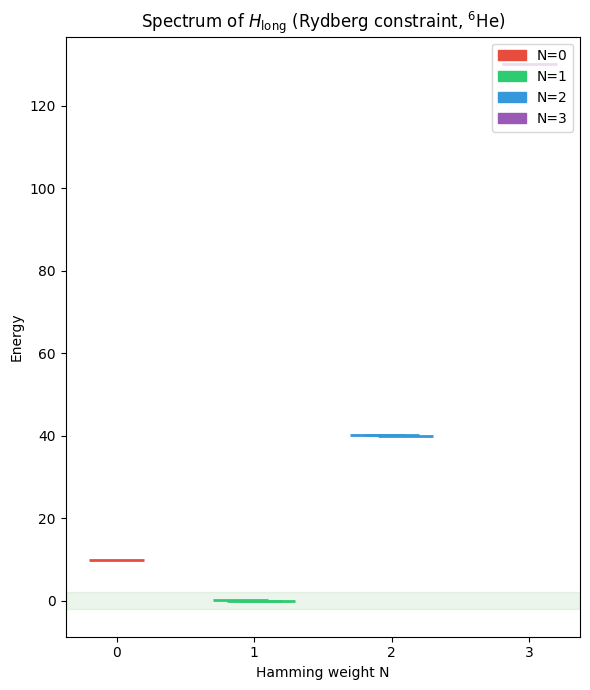

N=0 energy: [10.]
N=1 energies: [-0.0598 -0.0598  0.2713]
N=2 energies: [39.8803 40.2115 40.2115]


In [26]:
import matplotlib.patches as mpatches

diag_long = longitudinal_hamiltonian.diag().real
colors = {0: "#e74c3c", 1: "#2ecc71", 2: "#3498db", 3: "#9b59b6"}

fig, ax = plt.subplots(figsize=(6, 7))
for k_hw in range(n_qubits + 1):
    mask = hamming == k_hw
    energies = diag_long[mask]
    xs = k_hw + np.linspace(
        -0.1 * (len(energies) - 1) / 2, 0.1 * (len(energies) - 1) / 2, len(energies)
    )
    for x, e in zip(xs, energies):
        ax.hlines(e, x - 0.2, x + 0.2, colors=colors.get(k_hw, "gray"), lw=2)

e1 = diag_long[hamming == 1]
ax.axhspan(e1.min() - 2, e1.max() + 2, alpha=0.08, color="green", label="N=1 band")
ax.set_xticks(range(n_qubits + 1))
ax.set_xlabel("Hamming weight N")
ax.set_ylabel("Energy")
ax.set_title("Spectrum of $H_{\\rm long}$ (Rydberg constraint, $^6$He)")
patches = [mpatches.Patch(color=colors[k], label=f"N={k}") for k in range(n_qubits + 1)]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

print("N=0 energy:", diag_long[hamming == 0])
print("N=1 energies:", np.sort(diag_long[hamming == 1]))
print("N=2 energies:", np.sort(diag_long[hamming == 2]))

## 6. BW Effective Hamiltonian
Check that the effective Hamiltonian in the N=1 subspace reproduces the NSM $g_{AB}$ matrix.

In [27]:
Heff, Haa, Hdelta, idxs_N1, idxs_R = build_effective_hamiltonian(
    total_hamiltonian, basis, Delta, low_energy_k=1
)

Heff_dense = Heff.toarray().real

print("Effective Hamiltonian in N=1 subspace:")
print(np.round(Heff_dense, 4))
print()

# Compare off-diagonal elements to g_matrix
# In the N=1 basis, qubit A corresponds to state |0...1_A...0>
qubit_to_row = {}
for row, state_idx in enumerate(idxs_N1):
    q = np.where(basis[state_idx] == 1)[0][0]
    qubit_to_row[q] = row

print("Effective XY couplings vs NSM g_matrix:")
print(f"{'pair (A,B)':>12}  {'g_AB^eff':>12}  {'g_AB NSM':>12}  {'ratio':>8}")
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        g_eff = Heff_dense[qubit_to_row[i], qubit_to_row[j]] * gamma
        g_nsm = g_matrix[i, j]
        print(
            f"  ({i},{j}): {g_eff:>12.4f}  {g_nsm:>12.4f}  {g_eff/g_nsm if g_nsm!=0 else float('nan'):>8.4f}"
        )

H_AA block:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (0, 0)	(0.2713439538394873+0j)
  (1, 1)	(-0.059836046160512524+0j)
  (2, 2)	(-0.059836046160512524+0j)

H_RR diagonal: [10.    +0.j 40.2115+0.j 40.2115+0.j 39.8803+0.j]

Second-order correction (in units of 1/gamma):
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 9 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	(-4.699873991002217+0j)
  (0, 2)	(4.6998739910022005+0j)
  (0, 0)	(14.100085783762623+0j)
  (1, 0)	(-4.699873991002216+0j)
  (1, 2)	(-1.3046575284172734+0j)
  (1, 1)	(4.68211830605603+0j)
  (2, 0)	(4.6998739910022005+0j)
  (2, 2)	(4.682118306056024+0j)
  (2, 1)	(-1.3046575284172737+0j)
Effective Hamiltonian in N=1 subspace:
[[-1.1387  0.47   -0.47  ]
 [ 0.47   -0.528   0.1305]
 [-0.47    0.1305 -0.528 ]]

Effective XY couplings vs NSM g_matrix:
  pair (A,B)      g_AB^eff      g_AB NSM     ratio
  (0,1):       1.3047     

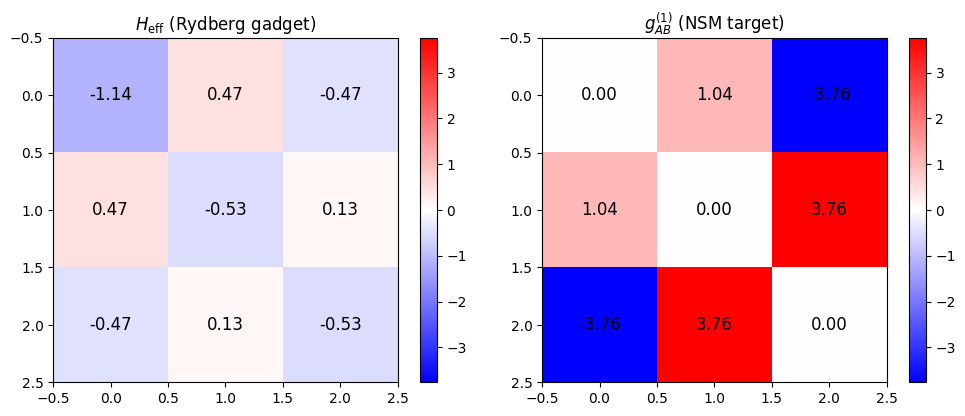

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(np.abs(Heff_dense).max(), np.abs(g_matrix).max())

for ax, mat, title in zip(
    axes,
    [Heff_dense, g_matrix],
    ["$H_{\\rm eff}$ (Rydberg gadget)", "$g_{AB}^{(1)}$ (NSM target)"],
):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=12)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Fidelity and energy error vs $\gamma$ (= $\Delta$)
Sweep $\Delta$ keeping $V = k\cdot\Delta$ fixed (blockade quality constant).
The gadget should improve as $\Delta \to \infty$ ($d_A / \Delta \to 0$).

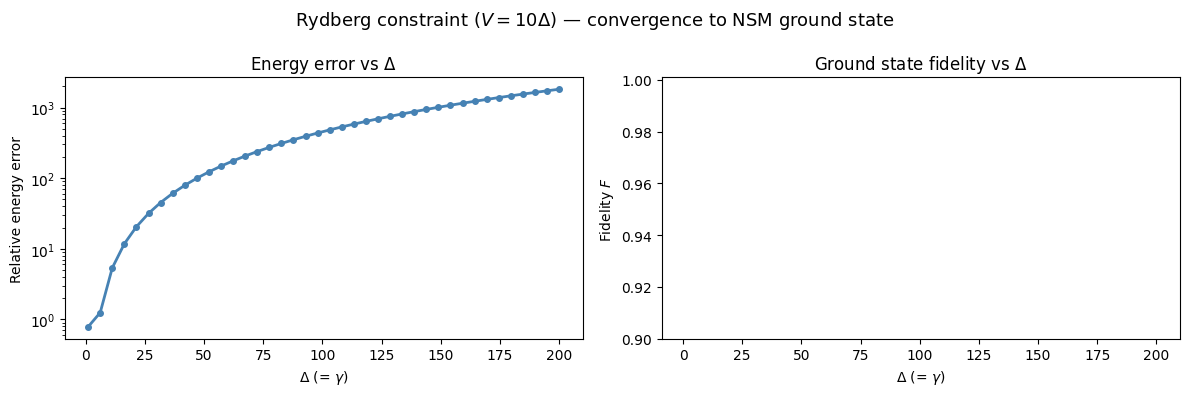

At Delta=200: fidelity = 0.000004, energy error = 1.82e+03


In [30]:
gammas = np.linspace(1, 200, 40)
energy_errors = []
fidelities = []

for gamma_val in gammas:
    Delta_val = gamma_val
    V_val = k * gamma_val

    # effective longitudinal field
    elf = (diagonal_elements + 0.5 * (d_opt**2).sum()) / Delta_val

    # N_A N_B block
    H_nn_g = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            H_nn_g += SpinOperator(
                [("qz", i, "qz", j)], coupling=[V_val], size=n_qubits, verbose=0
            ).qutip_op

    # linear N_A block
    H_n_g = 0.0
    for i in range(n_qubits):
        H_n_g += SpinOperator(
            [("qz", i)], coupling=[-Delta_val + elf[i]], size=n_qubits, verbose=0
        ).qutip_op

    # transverse field
    H_t_g = 0.0
    for i in range(n_qubits):
        H_t_g += SpinOperator(
            [("x", i)], coupling=[d_opt[i]], size=n_qubits, verbose=0
        ).qutip_op

    H_tot_g = H_nn_g + H_n_g + H_t_g
    evals, evecs = H_tot_g.eigenstates()

    # ground state energy: rescale by Delta to get NSM units
    E_gadget = evals[0] * Delta_val
    E_nsm = eigenvalues_nsm[idx]
    energy_errors.append(np.abs(E_gadget - E_nsm) / np.abs(E_nsm))
    fidelities.append(fidelity(evecs[0], eigenstates_nsm[idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(gammas, energy_errors, "o-", color="steelblue", lw=2, ms=4)
axes[0].set_xlabel("$\\Delta$ (= $\\gamma$)")
axes[0].set_ylabel("Relative energy error")
axes[0].set_title("Energy error vs $\\Delta$")

axes[1].plot(gammas, fidelities, "o-", color="tomato", lw=2, ms=4)
axes[1].set_xlabel("$\\Delta$ (= $\\gamma$)")
axes[1].set_ylabel("Fidelity $F$")
axes[1].set_title("Ground state fidelity vs $\\Delta$")
axes[1].set_ylim(0.9, 1.001)

plt.suptitle(
    "Rydberg constraint ($V = 10\\Delta$) — convergence to NSM ground state",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(
    f"At Delta=200: fidelity = {fidelities[-1]:.6f}, energy error = {energy_errors[-1]:.2e}"
)

## 8. Driver Hamiltonian and adiabatic state preparation

The driver is the same as in the original notebook — the constraint with only the
lowest-energy longitudinal field to initialise in the correct N=1 state.

In [31]:
gamma = 100.0
Delta = gamma
V = k * gamma

# Driver: Rydberg constraint + only the lowest-energy single-particle field
# (same logic as original notebook: external_field = [diagonal_elements[0], 0, 0])
external_field = np.zeros(n_qubits)
external_field[0] = diagonal_elements[0]
elf_driver = external_field / Delta

H_nn_drv = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        H_nn_drv += SpinOperator(
            [("qz", i, "qz", j)], coupling=[V], size=n_qubits, verbose=0
        ).qutip_op

H_n_drv = 0.0
for i in range(n_qubits):
    H_n_drv += SpinOperator(
        [("qz", i)], coupling=[-Delta + elf_driver[i]], size=n_qubits, verbose=0
    ).qutip_op

driver_hamiltonian = H_nn_drv + H_n_drv

# initial state: lowest-energy N=1 computational basis state
idx_init = np.argsort(driver_hamiltonian.diag().real)[0]
print("Initial state index:", idx_init, "-> basis state:", basis[idx_init])
print("Driver diagonal:", driver_hamiltonian.diag().real)

Initial state index: 4 -> basis state: [1 0 0]
Driver diagonal: [   0.     -100.     -100.      300.     -100.0843  299.9157  299.9157
 1199.9157]


In [ ]:
from scipy.sparse.linalg import expm_multiply

# Rebuild total hamiltonian at gamma=100
elf_total = (diagonal_elements + 0.5 * (d_opt**2).sum()) / Delta

H_nn_tot = 0.0
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        H_nn_tot += SpinOperator(
            [("qz", i, "qz", j)], coupling=[V], size=n_qubits, verbose=0
        ).qutip_op

H_n_tot = 0.0
for i in range(n_qubits):
    H_n_tot += SpinOperator(
        [("qz", i)], coupling=[-Delta + elf_total[i]], size=n_qubits, verbose=0
    ).qutip_op

H_t_tot = 0.0
for i in range(n_qubits):
    H_t_tot += SpinOperator(
        [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=0
    ).qutip_op

total_hamiltonian_final = H_nn_tot + H_n_tot + H_t_tot

# sparse matrices for time evolution
H_tot_sp = total_hamiltonian_final.data.as_scipy()
H_drv_sp = driver_hamiltonian.data.as_scipy()

# initial state
psi = np.zeros(2**n_qubits)
psi[idx_init] = 1.0

# adiabatic sweep
nlevels = 3
tau = 10 * gamma
time_steps = int(10 * tau)
time = np.linspace(0, tau, time_steps)
delta_t = time[1] - time[0]
spectrum = np.zeros((time_steps, nlevels))
energy = np.zeros(time_steps)

for step, t in enumerate(time):
    s = t / tau
    H_t_sp = (1 - s) * H_drv_sp + s * H_tot_sp
    psi = expm_multiply(-1j * delta_t * H_t_sp, psi)
    psi /= np.linalg.norm(psi)
    energy[step] = np.real(psi.conj() @ H_t_sp @ psi)

final_state = qt.Qobj(psi, dims=[[2] * n_qubits, [1] * n_qubits])
final_fidelity = fidelity(final_state, eigenstates_nsm[idx])
print(f"Final fidelity after adiabatic sweep (tau={tau:.0f}): {final_fidelity:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(time / tau, energy * Delta, lw=2)
plt.axhline(
    eigenvalues_nsm[idx],
    color="r",
    ls="--",
    label=f"NSM GS = {eigenvalues_nsm[idx]:.3f}",
)
plt.xlabel("$t/\\tau$")
plt.ylabel("Energy (NSM units)")
plt.title("Adiabatic evolution energy — Rydberg constraint")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary — Uniform vs Rydberg constraint comparison

| Property | Uniform $\gamma(\sum N_A-1)^2$ | Rydberg $V\sum N_AN_B - \Delta\sum N_A$ |
|---|---|---|
| Pair coupling | $2\gamma$ (all pairs) | $V$ (all pairs, triangle = uniform!) |
| Linear term | $\gamma(1-2n_{\rm tot})$ per site | $-\Delta$ per site |
| Identity shift | $+\gamma n_{\rm tot}^2$ | none needed |
| Effective $\gamma$ | $\gamma$ | $\Delta$ |
| $N=0$ gap | $\gamma$ | $\Delta$ |
| $N=2$ gap | $\gamma$ | $V - \Delta = (k-1)\Delta$ |
| $g_{AB}^{\rm eff}$ | $-d_Ad_B/\gamma$ | $-d_Ad_B/\Delta - d_Ad_B/(V-\Delta)$ |

For $n=3$ on an equilateral triangle the Rydberg constraint is **exactly equivalent**
to the uniform one in the limit $k \to \infty$ ($V \gg \Delta$), with $\gamma \to \Delta$.